
  <img src="https://github.com/gefero/factor_data_SICSS_Baires_2026/blob/main/imgs/logo_final_conjunto.png?raw=true" width="80%">


# Summer Institute in Computational Social Sciences - Buenos Aires 2026
# Taller: Procesamiento de Lenguaje Natural y polarización
# Clasificación de tweets con distintas representaciones: TF, TF-IDF y Word Embeddings

### Profesor: Germán Rosati


# Introducción

El objetivo de este notebook es comparar distintas formas de representar texto como *features* para un modelo de clasificación, usando como caso el dataset **HatEval** (SemEval-2019 Task 5), que ya vienen utilizando en las prácticas de este taller. El dataset viene dividido en tres splits, cada uno en su propio archivo dentro de `data/`:

- `hateval_train_df.csv`: split de **entrenamiento**. Lo usamos para ajustar (`fit`) cada modelo.
- `hateval_dev_df.csv`: split de **validación**. Lo usamos para elegir el mejor valor del hiperparámetro de regularización de cada modelo.
- `hateval_test_df.csv`: split de **test**. Lo usamos únicamente al final, para evaluar el desempeño de cada modelo sobre datos que no participaron ni del entrenamiento ni de la elección de hiperparámetros.

Cada fila de estos archivos es un tweet con las siguientes columnas relevantes:

- `id`: identificador del tweet
- `text`: el texto del tweet
- `language`: idioma del tweet (`en` o `es`)
- `HS`: 1 si el tweet contiene discurso de odio (*hate speech*), 0 en caso contrario
- `TR`, `AG`: otras anotaciones (agresividad, si el odio está dirigido a un individuo o a un grupo) que no vamos a usar acá

La tarea de clasificación va a ser predecir `HS` (discurso de odio sí/no) a partir del texto del tweet.

Como en la última sección vamos a usar **embeddings preentrenados en español** (SBWCE), y los tres splits tienen tweets tanto en inglés como en español, nos vamos a quedar solamente con los tweets en español (`language == 'es'`) de cada split para poder comparar las tres representaciones sobre los mismos datos.

Al igual que en el ejemplo con reseñas de Amazon (`cap0/ejemplo_clasificacion.ipynb`), vamos a entrenar en cada caso una regresión logística regularizada por LASSO (penalización L1), variando el hiperparámetro de regularización $C$ (a menor $C$, mayor regularización). A diferencia de ese ejemplo, acá **no** usamos validación cruzada (K-Fold) para elegir $C$: como ya contamos con un split de validación (`dev`) independiente, entrenamos cada candidato sobre `train` y elegimos el que mejor performa sobre `dev`. `test` queda completamente afuera de ese proceso, y solo se usa al final para reportar el desempeño de cada modelo ya elegido.

Vamos a comparar tres formas de vectorizar los tweets:

1. **TF** (*Term Frequency*, bolsa de palabras con conteos)
2. **TF-IDF** (*Term Frequency - Inverse Document Frequency*)
3. **Word embeddings preentrenados** (promedio de vectores de palabras)

Además de las métricas de desempeño (ROC AUC, accuracy, precision, recall, F1), en TF y TF-IDF vamos a mirar los coeficientes ($\beta$) del modelo para interpretar qué palabras aprendió a asociar con discurso de odio. Con embeddings esto no va a ser posible de la misma forma — lo vamos a explicar en esa sección.

In [ ]:
## Ejecutar para descargar los embeddings preentrenados en español (SBWCE)
!wget -P ./models https://cs.famaf.unc.edu.ar/~ccardellino/SBWCE/SBW-vectors-300-min5.bin.gz && gunzip ./models/SBW-vectors-300-min5.bin.gz
!pip install gensim
!apt-get -qq install -y git-lfs >/dev/null && git lfs install --skip-repo
!git clone https://github.com/gefero/factor_data_SICSS_Baires_2026.git

--2026-08-13 12:24:23--  https://cs.famaf.unc.edu.ar/~ccardellino/SBWCE/SBW-vectors-300-min5.bin.gz
Resolving cs.famaf.unc.edu.ar (cs.famaf.unc.edu.ar)... 200.16.17.55
Connecting to cs.famaf.unc.edu.ar (cs.famaf.unc.edu.ar)|200.16.17.55|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 1123304474 (1.0G) [application/x-gzip]
Saving to: ‘./models/SBW-vectors-300-min5.bin.gz’

SBW-vectors-300-min 100%[===================>]   1.05G  4.92MB/s    in 2m 31s  

2026-08-13 12:26:55 (7.10 MB/s) - ‘./models/SBW-vectors-300-min5.bin.gz’ saved [1123304474/1123304474]

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 69.1 MB/s eta 0:00:00
Cloning into 'factor_data_SICSS_Baires_2026'...
remote: Enumerating objects: 169, done.
remote: Counting objects: 100% (154/154), done.
remote: Compressing objects: 100% (110/110), done.
remote: Total 169 (delta 88), reused 107 (delta 43), pack-reused 15 (from 1)
Receiving objects: 100% (169/169), 63.84 MiB | 28.58 MiB/s, done.
Resol

# TF con LASSO

## Preparación de los datos

Cargamos los tres splits de HatEval (`hateval_train_df.csv`, `hateval_dev_df.csv` y `hateval_test_df.csv`), nos quedamos en cada uno con los tweets en español y preprocesamos el texto:

1. Convertimos a minúsculas
2. Eliminamos URLs y menciones (`@usuario`), que son ruido propio de los tweets
3. Eliminamos signos de puntuación
4. Reemplazamos números por la palabra `DIGITO`
5. Eliminamos acentos y caracteres no ASCII

Para cada split, `X` va a ser el texto preprocesado y `y` la variable binaria `HS` (discurso de odio).

In [ ]:
# Importamos las librerías necesarias
import pandas as pd
import numpy as np
from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.metrics import roc_auc_score, accuracy_score, precision_score, recall_score, f1_score
import re
import unicodedata
import warnings
warnings.filterwarnings('ignore')

In [ ]:
import os

# Soporta correr tanto desde el repo recién clonado (Colab) como localmente
train_path = './factor_data_SICSS_Baires_2026/data/hateval_train_df.csv'
dev_path = './factor_data_SICSS_Baires_2026/data/hateval_dev_df.csv'
test_path = './factor_data_SICSS_Baires_2026/data/hateval_test_df.csv'
if not os.path.exists(train_path):
    train_path = '../../data/hateval_train_df.csv'
    dev_path = '../../data/hateval_dev_df.csv'
    test_path = '../../data/hateval_test_df.csv'

In [ ]:
# Función para preprocesar el texto
def preprocess_text(text):
    # Convertir a minúsculas
    text = text.lower()

    # Eliminar URLs
    text = re.sub(r'https?://\S+|www\.\S+', ' ', text)

    # Eliminar menciones (@usuario)
    text = re.sub(r'@\w+', ' ', text)

    # Reemplazar puntuación
    text = re.sub(r'[^\w\s]', ' ', text)

    # Reemplazar números por 'DIGITO'
    text = re.sub(r'\d+', 'DIGITO', text)

    # Reemplazar caracteres no ASCII (acentos, etc.)
    text = unicodedata.normalize('NFKD', text).encode('ASCII', 'ignore').decode('utf-8')

    # Colapsar espacios múltiples
    text = re.sub(r'\s+', ' ', text).strip()

    return text

# Cargamos un split y nos quedamos con los tweets en español
def load_hateval_split(path):
    df = pd.read_csv(path)
    df = df[df['language'] == 'es'].reset_index(drop=True)
    df['text_clean'] = df['text'].apply(preprocess_text)
    return df

train_df = load_hateval_split(train_path)
dev_df = load_hateval_split(dev_path)
test_df = load_hateval_split(test_path)

# Preparamos las variables para el modelo
X_train, y_train = train_df['text_clean'], train_df['HS']
X_dev, y_dev = dev_df['text_clean'], dev_df['HS']
X_test, y_test = test_df['text_clean'], test_df['HS']

print(f"Train: {len(X_train)} tweets | Dev: {len(X_dev)} tweets | Test: {len(X_test)} tweets")

Train: 4500 tweets | Dev: 500 tweets | Test: 1599 tweets


## Cómo se ve una matriz de Term Frequency

Antes de armar el pipeline completo, vale la pena ver qué produce realmente un `CountVectorizer`: una matriz donde cada fila es un documento (tweet) y cada columna una palabra del vocabulario, con la cantidad de veces que esa palabra aparece en ese documento.

Usamos acá solo 4 oraciones cortas de ejemplo (no el corpus completo) y solo unigramas, para que la matriz sea chica y legible. Con miles de tweets y ngramas de 1-2 palabras como en la sección siguiente, esta misma matriz tendría decenas de miles de columnas y sería casi toda ceros (una matriz **dispersa**, *sparse*), por eso sklearn la guarda en un formato disperso en vez de como un array denso.

In [ ]:
# Oraciones de ejemplo (no son parte del dataset, son solo para ilustrar)
ejemplo_tweets = [
    "no me gustan los inmigrantes en mi barrio",
    "los inmigrantes trabajan mucho en mi barrio",
    "amo la diversidad y a los inmigrantes",
    "odio a la gente que no piensa como yo",
]

# Solo unigramas acá, a diferencia del pipeline real (1-2 gramas), para que
# el vocabulario resultante sea chico y la matriz se pueda leer de un vistazo
vectorizer_ejemplo = CountVectorizer(ngram_range=(1, 1))
matriz_ejemplo = vectorizer_ejemplo.fit_transform(ejemplo_tweets)

# Convertimos la matriz dispersa a un DataFrame denso solo para visualizarla
# (con el corpus real, nunca convertirías la matriz completa a denso: no entraría en memoria)
tf_df = pd.DataFrame(
    matriz_ejemplo.toarray(),
    columns=vectorizer_ejemplo.get_feature_names_out(),
    index=[f'tweet {i+1}' for i in range(len(ejemplo_tweets))]
)
tf_df

,amo,barrio,como,diversidad,en,gente,gustan,inmigrantes,la,los,me,mi,mucho,no,odio,piensa,que,trabajan,yo
tweet 1,0,1,0,0,1,0,1,1,0,1,1,1,0,1,0,0,0,0,0
tweet 2,0,1,0,0,1,0,0,1,0,1,0,1,1,0,0,0,0,1,0
tweet 3,1,0,0,1,0,0,0,1,1,1,0,0,0,0,0,0,0,0,0
tweet 4,0,0,1,0,0,1,0,0,1,0,0,0,0,1,1,1,1,0,1


## Búsqueda de hiperparámetros usando el split de validación

En scikit-learn, un `Pipeline` es una herramienta que te permite encadenar múltiples pasos de procesamiento (como preprocesamiento de datos, extracción de características y entrenamiento de modelos) en un único objeto cohesivo. Ayuda a optimizar los flujos de trabajo, prevenir la fuga de datos y asegurar que las mismas transformaciones se apliquen consistentemente a diferentes conjuntos de datos (por ejemplo, conjuntos de entrenamiento, validación y prueba). En lugar de aplicar cada paso manualmente, defines la secuencia de operaciones y el objeto `Pipeline` se encarga de la ejecución en el orden correcto.

Armamos un pipeline con:

1. **Vectorización TF**: `CountVectorizer` con ngramas de 1 y 2 palabras
2. **Regresión logística LASSO** (penalización L1, solver `liblinear`)

Para elegir el mejor valor de `C` (inverso de la fuerza de regularización) probamos 30 valores en escala logarítmica entre $10^{-10}$ y $10^{1}$: para cada uno, entrenamos el pipeline sobre `train` y calculamos el ROC AUC sobre `dev`. Nos quedamos con el `C` que da mejor ROC AUC en `dev`.

In [ ]:
# Creamos una grilla de valores para el parámetro C (inverso de la penalización)
C_values = np.logspace(-10, 1, 30)

# Pipeline con TF y LASSO
pipeline_tf = Pipeline([
    ('vectorizer', CountVectorizer(
        ngram_range=(1, 2),
        token_pattern=r'\b\w+\b'
    )),
    ('classifier', LogisticRegression(
        penalty='l1',
        solver='liblinear',
        random_state=234
    ))
])

# Almacenaremos los resultados de la búsqueda aquí
val_results = []

In [ ]:
%%time
# Para cada valor de C
for C in C_values:
    pipeline_tf.set_params(classifier__C=C)

    # Entrenamos sobre train y evaluamos sobre dev
    pipeline_tf.fit(X_train, y_train)
    dev_proba = pipeline_tf.predict_proba(X_dev)[:, 1]

    val_results.append({
        'C': C,
        'roc_auc_dev': roc_auc_score(y_dev, dev_proba)
    })

# Convertimos resultados a DataFrame
val_results_df = pd.DataFrame(val_results)

# Encontramos el mejor C
best_idx = val_results_df['roc_auc_dev'].idxmax()
best_C_tf = val_results_df.loc[best_idx, 'C']

print(f"Mejor valor de C: {best_C_tf:.6f}")
print(f"Mejor ROC AUC (dev): {val_results_df.loc[best_idx, 'roc_auc_dev']:.3f}")

Mejor valor de C: 0.727895
Mejor ROC AUC (dev): 0.895
CPU times: user 18.9 s, sys: 284 ms, total: 19.2 s
Wall time: 31.1 s


## Modelo final

Entrenamos el pipeline final sobre `train` con el mejor valor de `C` encontrado y evaluamos sobre `test` (que no participó ni del entrenamiento ni de la elección de hiperparámetros) con ROC AUC, accuracy, precision, recall y F1.

In [ ]:
# Ajustamos el modelo final con el mejor C
final_pipeline_tf = Pipeline([
    ('vectorizer', CountVectorizer(
        ngram_range=(1, 2),
        token_pattern=r'\b\w+\b'
    )),
    ('classifier', LogisticRegression(
        C=best_C_tf,
        penalty='l1',
        solver='liblinear',
        random_state=234
    ))
])

final_pipeline_tf.fit(X_train, y_train)
y_pred = final_pipeline_tf.predict(X_test)
y_pred_proba = final_pipeline_tf.predict_proba(X_test)[:, 1]

# Métricas finales
results_tf = {
    'roc_auc': roc_auc_score(y_test, y_pred_proba),
    'accuracy': accuracy_score(y_test, y_pred),
    'precision': precision_score(y_test, y_pred),
    'recall': recall_score(y_test, y_pred),
    'f1': f1_score(y_test, y_pred)
}

for metric, value in results_tf.items():
    print(f"{metric}: {value:.3f}")

roc_auc: 0.777
accuracy: 0.710
precision: 0.636
recall: 0.697
f1: 0.665


## Interpretación de los coeficientes

Como el clasificador es una regresión logística **lineal** sobre features interpretables (cada columna del vectorizador es una palabra o bigrama), podemos mirar directamente los coeficientes (`coef_`) para ver qué aprendió el modelo — no hace falta ninguna técnica de interpretabilidad externa (SHAP, LIME, etc.).

Dos cosas para tener en cuenta al leerlos:

- **LASSO selecciona variables**: la penalización L1 empuja a *exactamente cero* los coeficientes de la enorme mayoría de las ~64 mil columnas del vocabulario. Solo un puñado de n-gramas "sobrevive" con coeficiente distinto de cero — son los que el modelo realmente usa para predecir.
- **Signo y magnitud**: un coeficiente positivo empuja la predicción hacia `HS=1` (discurso de odio); uno negativo, hacia `HS=0`. Como acá el vectorizador es `CountVectorizer` (conteos crudos), `exp(beta)` tiene una lectura directa como **odds ratio**: "cada aparición adicional de este término multiplica las odds de que el tweet sea odio por `exp(beta)`" (manteniendo todo lo demás constante).

Nota: como el dataset es de discurso de odio, es esperable que los términos con coeficiente más alto incluyan insultos explícitos — es justamente lo que estamos buscando ver.

In [ ]:
# Extraemos el vocabulario del vectorizador y los coeficientes del clasificador
# (mismo orden: la posición i del vocabulario corresponde a coef_[0][i])
feature_names_tf = final_pipeline_tf.named_steps['vectorizer'].get_feature_names_out()
coefs_tf = final_pipeline_tf.named_steps['classifier'].coef_[0]

coef_df_tf = pd.DataFrame({'feature': feature_names_tf, 'coef': coefs_tf})
coef_df_tf['odds_ratio'] = np.exp(coef_df_tf['coef'])

n_total = len(coef_df_tf)
n_nonzero = int((coef_df_tf['coef'] != 0).sum())
print(f"Features totales: {n_total} | con coeficiente != 0 (seleccionadas por LASSO): "
      f"{n_nonzero} ({n_nonzero / n_total * 100:.1f}%)")

top_pos_tf = coef_df_tf.sort_values('coef', ascending=False).head(15)
top_neg_tf = coef_df_tf.sort_values('coef', ascending=True).head(15)

print("\nTop 15 términos que más empujan hacia HS=1 (discurso de odio):")
display(top_pos_tf)

print("\nTop 15 términos que más empujan hacia HS=0 (no odio):")
display(top_neg_tf)

Features totales: 64221 | con coeficiente != 0 (seleccionadas por LASSO): 739 (1.2%)

Top 15 términos que más empujan hacia HS=1 (discurso de odio):


,feature,coef,odds_ratio
37817,moromierdas,3.726709,41.542161
61649,viejas,3.219657,25.019537
37833,moros,2.820802,16.790304
22878,feminazis,2.396356,10.983086
64085,zorra,2.389023,10.902837
6920,callate puta,2.385308,10.862403
55220,sudacas,2.344845,10.431659
43326,pendeja,2.280230,9.778928
55185,sudaca,2.049448,7.763615
22767,fea,2.031952,7.628960



Top 15 términos que más empujan hacia HS=0 (no odio):


,feature,coef,odds_ratio
20322,escoria,-3.010568,0.049264
47624,puta vez,-2.655253,0.070281
26536,hijo,-2.079229,0.125027
26542,hijo de,-2.063134,0.127055
47445,puta madre,-1.972281,0.139139
47481,puta mierda,-1.953543,0.141771
26941,hostia puta,-1.915046,0.147335
30667,la puta,-1.871584,0.153880
36703,mi perra,-1.831496,0.160174
43959,perra ni,-1.643221,0.193356


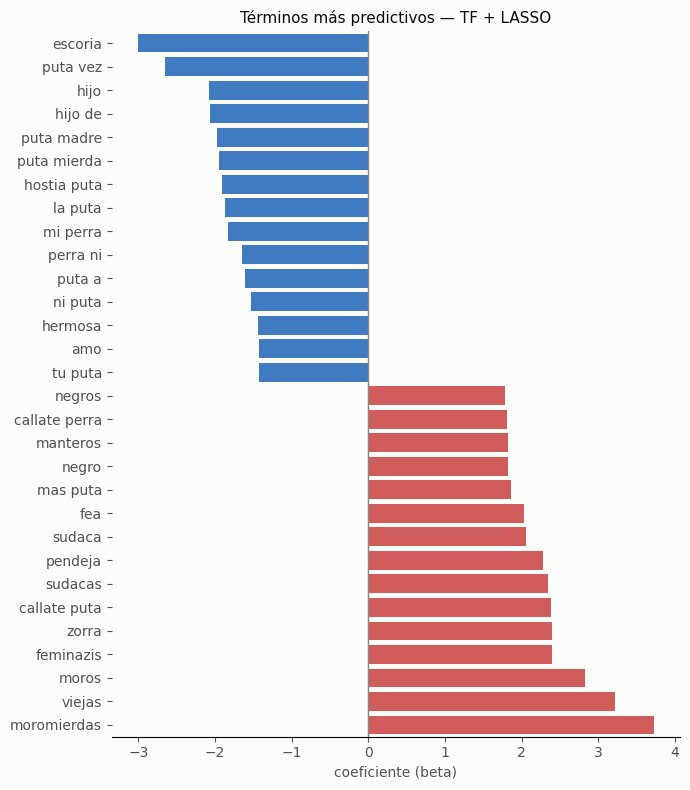

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Combinamos los 15+15 términos y los ordenamos por coeficiente para el gráfico
top_terms_tf = pd.concat([top_neg_tf, top_pos_tf]).sort_values('coef')

# Codificación diverging: rojo = empuja hacia odio, azul = empuja hacia no-odio
# (los colores de identidad TF/TF-IDF del resto del notebook no aplican acá:
# esto codifica la clase, no la representación)
colors_coef = ['#e34948' if c > 0 else '#2a78d6' for c in top_terms_tf['coef']]

fig, ax = plt.subplots(figsize=(7, 8))
fig.patch.set_facecolor('#fcfcfb')
sns.barplot(data=top_terms_tf, x='coef', y='feature', hue='feature',
            palette=colors_coef, legend=False, ax=ax)
ax.axvline(0, color='#898781', linewidth=1)
ax.set_facecolor('#fcfcfb')
ax.set_xlabel('coeficiente (beta)', color='#52514e')
ax.set_ylabel('')
ax.set_title('Términos más predictivos — TF + LASSO', color='#0b0b0b', fontsize=11)
ax.tick_params(colors='#52514e')
sns.despine(ax=ax, left=True)
fig.tight_layout()
plt.show()

# TF-IDF con LASSO

A diferencia de TF (que solo cuenta ocurrencias), **TF-IDF** pondera cada término según qué tan frecuente es dentro de un tweet (TF) pero penalizando los términos que aparecen en muchos tweets distintos (IDF). Esto suele darle más peso a palabras discriminativas y menos a palabras muy comunes.

Reutilizamos los mismos `X_train`/`y_train`, `X_dev`/`y_dev` y `X_test`/`y_test` de la sección anterior, y repetimos el mismo procedimiento (elegir `C` con el split de validación y evaluar sobre test) pero con `TfidfVectorizer` en lugar de `CountVectorizer`.

In [ ]:
# Pipeline con TF-IDF y LASSO
pipeline_tfidf = Pipeline([
    ('vectorizer', TfidfVectorizer(
        ngram_range=(1, 2),
        token_pattern=r'\b\w+\b'
    )),
    ('classifier', LogisticRegression(
        penalty='l1',
        solver='liblinear',
        random_state=234
    ))
])

val_results = []

In [ ]:
C_values

array([1.00000000e-10, 2.39502662e-10, 5.73615251e-10, 1.37382380e-09,
       3.29034456e-09, 7.88046282e-09, 1.88739182e-08, 4.52035366e-08,
       1.08263673e-07, 2.59294380e-07, 6.21016942e-07, 1.48735211e-06,
       3.56224789e-06, 8.53167852e-06, 2.04335972e-05, 4.89390092e-05,
       1.17210230e-04, 2.80721620e-04, 6.72335754e-04, 1.61026203e-03,
       3.85662042e-03, 9.23670857e-03, 2.21221629e-02, 5.29831691e-02,
       1.26896100e-01, 3.03919538e-01, 7.27895384e-01, 1.74332882e+00,
       4.17531894e+00, 1.00000000e+01])

In [ ]:
%%time
for C in C_values:
    pipeline_tfidf.set_params(classifier__C=C)

    pipeline_tfidf.fit(X_train, y_train)
    dev_proba = pipeline_tfidf.predict_proba(X_dev)[:, 1]

    val_results.append({
        'C': C,
        'roc_auc_dev': roc_auc_score(y_dev, dev_proba)
    })

val_results_df = pd.DataFrame(val_results)

best_idx = val_results_df['roc_auc_dev'].idxmax()
best_C_tfidf = val_results_df.loc[best_idx, 'C']

print(f"Mejor valor de C: {best_C_tfidf:.6f}")
print(f"Mejor ROC AUC (dev): {val_results_df.loc[best_idx, 'roc_auc_dev']:.3f}")

Mejor valor de C: 10.000000
Mejor ROC AUC (dev): 0.899
CPU times: user 16.8 s, sys: 89.4 ms, total: 16.9 s
Wall time: 18.3 s


In [ ]:
# Ajustamos el modelo final con el mejor C
final_pipeline_tfidf = Pipeline([
    ('vectorizer', TfidfVectorizer(
        ngram_range=(1, 2),
        token_pattern=r'\b\w+\b'
    )),
    ('classifier', LogisticRegression(
        C=best_C_tfidf,
        penalty='l1',
        solver='liblinear',
        random_state=234
    ))
])

final_pipeline_tfidf.fit(X_train, y_train)
y_pred = final_pipeline_tfidf.predict(X_test)
y_pred_proba = final_pipeline_tfidf.predict_proba(X_test)[:, 1]

results_tfidf = {
    'roc_auc': roc_auc_score(y_test, y_pred_proba),
    'accuracy': accuracy_score(y_test, y_pred),
    'precision': precision_score(y_test, y_pred),
    'recall': recall_score(y_test, y_pred),
    'f1': f1_score(y_test, y_pred)
}

for metric, value in results_tfidf.items():
    print(f"{metric}: {value:.3f}")

roc_auc: 0.773
accuracy: 0.684
precision: 0.591
recall: 0.759
f1: 0.665


## Interpretación de los coeficientes

Repetimos el mismo análisis que en la sección de TF, pero con una diferencia importante en cómo se leen los coeficientes acá.

- **LASSO sigue seleccionando variables**: de nuevo, la gran mayoría de los coeficientes del vocabulario quedan en cero; solo sobrevive un subconjunto chico.
- **El odds ratio ya no tiene la misma lectura "por ocurrencia".** En TF cada feature era un conteo entero (0, 1, 2, ...), así que `exp(beta)` se interpretaba como "cuánto multiplica las odds cada aparición adicional". Acá cada feature es un **score TF-IDF continuo**: pondera la frecuencia del término en el tweet por qué tan raro es en todo el corpus (IDF), y además cada vector de tweet se normaliza (norma L2). Un "incremento de una unidad" en ese score no corresponde a nada tan intuitivo como "una palabra más"; por eso acá **no** mostramos la columna de odds ratio. El signo (empuja hacia `HS=1` o `HS=0`) y el orden relativo entre términos siguen siendo perfectamente interpretables; lo que se pierde es la lectura "por ocurrencia" en unidades naturales.

In [ ]:
feature_names_tfidf = final_pipeline_tfidf.named_steps['vectorizer'].get_feature_names_out()
coefs_tfidf = final_pipeline_tfidf.named_steps['classifier'].coef_[0]

coef_df_tfidf = pd.DataFrame({'feature': feature_names_tfidf, 'coef': coefs_tfidf})

n_total = len(coef_df_tfidf)
n_nonzero = int((coef_df_tfidf['coef'] != 0).sum())
print(f"Features totales: {n_total} | con coeficiente != 0 (seleccionadas por LASSO): "
      f"{n_nonzero} ({n_nonzero / n_total * 100:.1f}%)")

top_pos_tfidf = coef_df_tfidf.sort_values('coef', ascending=False).head(15)
top_neg_tfidf = coef_df_tfidf.sort_values('coef', ascending=True).head(15)

print("\nTop 15 términos que más empujan hacia HS=1 (discurso de odio):")
display(top_pos_tfidf)

print("\nTop 15 términos que más empujan hacia HS=0 (no odio):")
display(top_neg_tfidf)

Features totales: 64221 | con coeficiente != 0 (seleccionadas por LASSO): 1825 (2.8%)

Top 15 términos que más empujan hacia HS=1 (discurso de odio):


,feature,coef
37817,moromierdas,35.073312
64085,zorra,32.069226
37833,moros,30.140054
43835,perra,29.730302
61649,viejas,27.808028
22878,feminazis,24.547025
55220,sudacas,22.501328
55185,sudaca,22.347712
43326,pendeja,22.311839
56412,te pones,21.811722



Top 15 términos que más empujan hacia HS=0 (no odio):


,feature,coef
20322,escoria,-29.722014
30667,la puta,-26.420005
26542,hijo de,-26.111888
26536,hijo,-26.046271
47445,puta madre,-25.295227
47624,puta vez,-20.658460
36703,mi perra,-18.070520
1174,acoso,-18.016869
47481,puta mierda,-16.945665
26941,hostia puta,-16.413029


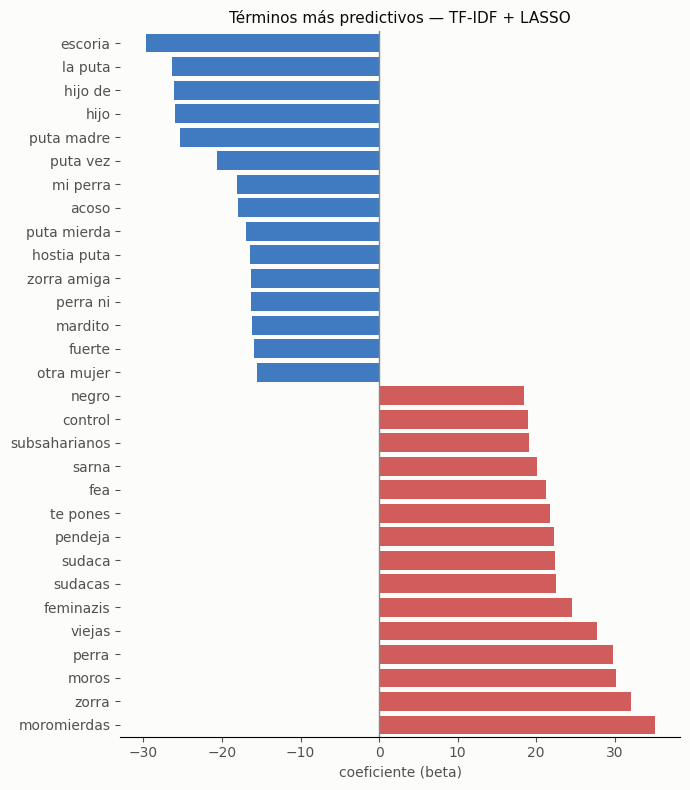

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

top_terms_tfidf = pd.concat([top_neg_tfidf, top_pos_tfidf]).sort_values('coef')
colors_coef = ['#e34948' if c > 0 else '#2a78d6' for c in top_terms_tfidf['coef']]

fig, ax = plt.subplots(figsize=(7, 8))
fig.patch.set_facecolor('#fcfcfb')
sns.barplot(data=top_terms_tfidf, x='coef', y='feature', hue='feature',
            palette=colors_coef, legend=False, ax=ax)
ax.axvline(0, color='#898781', linewidth=1)
ax.set_facecolor('#fcfcfb')
ax.set_xlabel('coeficiente (beta)', color='#52514e')
ax.set_ylabel('')
ax.set_title('Términos más predictivos — TF-IDF + LASSO', color='#0b0b0b', fontsize=11)
ax.tick_params(colors='#52514e')
sns.despine(ax=ax, left=True)
fig.tight_layout()
plt.show()

## Análisis cualitativo de errores (FP y FN)

Los coeficientes de arriba muestran qué términos aislados usa el modelo, pero no explican por qué se equivoca en un tweet concreto: combinaciones de palabras, ironía, negación o contexto que un modelo bag-of-words no puede captar. Miramos una muestra chica (**no representativa, solo ilustrativa**) de errores del modelo TF-IDF + LASSO sobre `test`:

- **Falsos positivos (FP)**: el modelo predijo `HS=1` (odio) y en realidad era `HS=0`.
- **Falsos negativos (FN)**: el modelo predijo `HS=0` y en realidad era `HS=1` (odio).

En vez de tomar una muestra al azar, ordenamos los errores por la probabilidad predicha y nos quedamos con los más "confiados" del modelo: los FP con la probabilidad más alta (el modelo estaba casi seguro de que era odio) y los FN con la probabilidad más baja (estaba casi seguro de que no lo era). Son los casos más informativos para pensar los límites del enfoque, más que un desacierto al borde del umbral de 0.5.


In [ ]:
n_ejemplos = 5

# Predicciones del modelo TF-IDF + LASSO sobre test (test_df tiene índice 0..n-1
# por el reset_index(drop=True) en load_hateval_split, alineado con el orden
# de X_test/y_test y por lo tanto con estos arrays de predicción)
y_pred_tfidf = final_pipeline_tfidf.predict(X_test)
y_pred_proba_tfidf = final_pipeline_tfidf.predict_proba(X_test)[:, 1]

errores_df = test_df[['text']].copy()
errores_df['y_true'] = y_test.values
errores_df['y_pred'] = y_pred_tfidf
errores_df['proba'] = y_pred_proba_tfidf

falsos_positivos = errores_df[(errores_df['y_true'] == 0) & (errores_df['y_pred'] == 1)]
falsos_negativos = errores_df[(errores_df['y_true'] == 1) & (errores_df['y_pred'] == 0)]

print(f"Falsos positivos: {len(falsos_positivos)} de {len(errores_df)} tweets en test")
print(f"Falsos negativos: {len(falsos_negativos)} de {len(errores_df)} tweets en test")

# FP más "confiados": proba más cercana a 1 (el modelo predijo HS con mucha seguridad)
fp_muestra = falsos_positivos.sort_values('proba', ascending=False).head(n_ejemplos)
# FN más "confiados": proba más cercana a 0 (el modelo predijo no-HS con mucha seguridad)
fn_muestra = falsos_negativos.sort_values('proba', ascending=True).head(n_ejemplos)

print("\n--- Falsos Positivos: predijo HS=1, en realidad era HS=0 ---")
for _, row in fp_muestra.iterrows():
    print(f"[p(HS)={row['proba']:.2f}] {row['text']}")

print("\n--- Falsos Negativos: predijo HS=0, en realidad era HS=1 ---")
for _, row in fn_muestra.iterrows():
    print(f"[p(HS)={row['proba']:.2f}] {row['text']}")


Falsos positivos: 346 de 1599 tweets en test
Falsos negativos: 159 de 1599 tweets en test

--- Falsos Positivos: predijo HS=1, en realidad era HS=0 ---
[p(HS)=1.00] @MifasolMaite Sudaca? K racista eres
[p(HS)=1.00] @TomiiVelardez @SanLorenzo Recopa sudaca, recopa Mercosur no la jugamos
[p(HS)=1.00] puta la madre, tu eres una mujer muy guapa @Camila_Cabello
[p(HS)=1.00] @tatefx_ TU ERES LA PINCHE PUTA EN ESTA AMISTAD
[p(HS)=1.00] @_Laindecisa_ @AndresCadavid26 Que ganen la sudaca, amén.

--- Falsos Negativos: predijo HS=0, en realidad era HS=1 ---
[p(HS)=0.00] Te vas a rer de tu puta madre, sudaca de mierda, hijo de puta, hijo de la grandsima puta.
[p(HS)=0.00] @dariogomez @Negl0o Cállate hijo de tu puta madre maldito fascista de mierda neo nazi tecnócrata fallido vas y chingas a tu madre!!
[p(HS)=0.00] @NunkMasKK @Marcami76 CALLATE HIJO DE PUTA ESBIRRO LA DICTADURA LA VIVIAMOS CON TU PUTA LA ABOGADATRUCHA
[p(HS)=0.00] @lafoca480 @CaraotaDigital callate maldito arrastrado hijo de puta!!

## Análisis cualitativo de aciertos (TP y TN)

Como contraparte de los errores, miramos también los aciertos más claros del modelo: verdaderos positivos (TP, predijo `HS=1` y era `HS=1`) y verdaderos negativos (TN, predijo `HS=0` y era `HS=0`), tomando de nuevo los casos donde el modelo estuvo más "confiado" (proba más cercana a 1 para TP, más cercana a 0 para TN).

Sirve como control de lo que vimos en FP/FN: si los TP están llenos de insultos/slurs explícitos y los TN de tweets "neutros", es una señal de que el modelo acierta por las razones esperables (términos de odio puntuales) y no por casualidad o por un desbalance de clases que infla la accuracy.


In [ ]:
verdaderos_positivos = errores_df[(errores_df['y_true'] == 1) & (errores_df['y_pred'] == 1)]
verdaderos_negativos = errores_df[(errores_df['y_true'] == 0) & (errores_df['y_pred'] == 0)]

print(f"Verdaderos positivos: {len(verdaderos_positivos)} de {len(errores_df)} tweets en test")
print(f"Verdaderos negativos: {len(verdaderos_negativos)} de {len(errores_df)} tweets en test")

# TP más "confiados": proba más cercana a 1
tp_muestra = verdaderos_positivos.sort_values('proba', ascending=False).head(n_ejemplos)
# TN más "confiados": proba más cercana a 0
tn_muestra = verdaderos_negativos.sort_values('proba', ascending=True).head(n_ejemplos)

print("\n--- Verdaderos Positivos: predijo HS=1, era HS=1 ---")
for _, row in tp_muestra.iterrows():
    print(f"[p(HS)={row['proba']:.2f}] {row['text']}")

print("\n--- Verdaderos Negativos: predijo HS=0, era HS=0 ---")
for _, row in tn_muestra.iterrows():
    print(f"[p(HS)={row['proba']:.2f}] {row['text']}")


Verdaderos positivos: 501 de 1599 tweets en test
Verdaderos negativos: 593 de 1599 tweets en test

--- Verdaderos Positivos: predijo HS=1, era HS=1 ---
[p(HS)=1.00] @segoviasof cállate perra
[p(HS)=1.00] @VeroBenavides7 cállate perra
[p(HS)=1.00] Cállate perra!!! https://t.co/aUVQMUoUH3
[p(HS)=1.00] ¡Cállate perra! https://t.co/tcarG6Sbaa
[p(HS)=1.00] @Luciileiva08 Cállate perra

--- Verdaderos Negativos: predijo HS=0, era HS=0 ---
[p(HS)=0.00] CALLATE !! CHACHALACA. CORRUPTO HIJO DE TU PUTA MADRE . https://t.co/n5PviDlwwO
[p(HS)=0.00] @sanlopezro72 @AlfonsoRojoPD Tú eres un descerebrado hijo de la puta más tirada
[p(HS)=0.00] @cejotaese CALLATE PELADO HIJO DE PUTA
[p(HS)=0.00] Vamos la puta madre!! SEMIFINALISTAS CARAJOOO 💛💛💛 AMO ESTE FANDOM AMO SER VIGNISTA! TE MERECES TODO @flor_vigna 👑👑👑
[p(HS)=0.00] @Independiente @CONMEBOL Cállate hijo de puta


### Qué explican estos ejemplos

- **Falsos positivos: el modelo detecta la palabra, no la función que cumple.** Los FP comparten un patrón claro: **"sudaca" o "puta" aparecen en el tweet, pero no están funcionando como insulto dirigido**. Hay tweets que citan el insulto para señalar el racismo de otra persona ("Sudaca? K racista eres"), no lo cometen; jerga futbolera ("sudaca" como apodo informal de un torneo/equipo sudamericano); interjecciones de asombro o admiración ("puta la madre... qué guapa"), muy comunes en el habla rioplatense — profanidad usada como intensificador, no como insulto; e insultos interpersonales puntuales que, aunque usan lenguaje misógino, no expresan odio sistémico hacia un grupo (recordá que HatEval define `HS=1` específicamente como odio **dirigido a mujeres o inmigrantes como grupo**, no cualquier insulto que use esas palabras). El límite estructural es el mismo que vimos con la matriz TF de ejemplo: bag-of-words (y TF-IDF) no tiene forma de representar negación, cita, ironía o función pragmática: solo detecta *presencia* de un término con peso alto.

- **Falsos negativos: "hijo de puta" actúa como señal *protectora*.** Los FN comparten algo muy específico: usan **"hijo de puta" / "hijo de tu puta madre"** como parte central del insulto y esa frase es, en la tabla de coeficientes de la sección anterior, uno de los términos **más negativos** del modelo. En el training set, "hijo de puta" aparece mayormente en insultos genéricos a políticos, instituciones, hombres y no en discurso de odio hacia mujeres o inmigrantes *como grupo*, así que el modelo parece haber aprendido, correctamente desde el punto de vista estadístico, que esa frase predice `HS=0`. El problema es que TF-IDF suma contribuciones de features de forma lineal e independiente (sin interacciones): cuando un tweet combina "hijo de puta" (señal negativa fuerte) con un slur real como "sudaca de mierda" (señal positiva), el peso negativo puede cancelar al positivo y arrastrar la predicción hacia `HS=0`, aunque el tweet sí contenga odio étnico real.

El modelo funciona como detector de un patrón corto.Los verdaderos positivos son reveladores: la mayoría son variaciones de **"cállate perra"** (el bigrama que vimos como uno de los coeficientes positivos más fuertes). El modelo es muy preciso para ese patrón formulaico (imperativo + insulto de género), pero se rompe en tweets largos, con insultos políticos mezclados, o donde el slur cumple una función distinta a la de atacar directamente a alguien.

# Word embeddings como features

## Idea general

En lugar de representar cada tweet como un vector disperso de conteos (TF) o pesos (TF-IDF) sobre el vocabulario, ahora vamos a representarlo como el **promedio de los vectores de embedding preentrenados** de sus palabras. Usamos los embeddings estáticos en español **SBWCE** (`SBW-vectors-300-min5`, ya descargados al inicio del notebook), donde cada palabra se representa con un vector denso de 300 dimensiones.

El preprocesamiento acá es más simple: solo eliminamos URLs y menciones, y reemplazamos números por `DIGITO`. No hace falta sacar puntuación ni acentos porque las palabras que no estén en el vocabulario de los embeddings simplemente se ignoran (*out-of-vocabulary*).

Como en las secciones anteriores, vectorizamos por separado los tweets en español de `train`, `dev` y `test`.

In [ ]:
import pandas as pd
import numpy as np
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score, accuracy_score, precision_score, recall_score, f1_score
import re
from gensim.models import KeyedVectors
import nltk
from nltk.tokenize import word_tokenize
import warnings
warnings.filterwarnings('ignore')

# Descargas necesarias para tokenización
nltk.download('punkt_tab')
nltk.download('punkt')

# Preprocesamiento simple: solo removemos URLs, menciones y reemplazamos dígitos
def preprocess_text_embed(text):
    text = re.sub(r'https?://\S+|www\.\S+', ' ', text)
    text = re.sub(r'@\w+', ' ', text)
    text = re.sub(r'\d+', 'DIGITO', text)
    return text

# Cargamos un split y nos quedamos con los tweets en español
def load_hateval_split_embed(path):
    df = pd.read_csv(path)
    df = df[df['language'] == 'es'].reset_index(drop=True)
    df['text_clean'] = df['text'].apply(preprocess_text_embed)
    return df

train_df = load_hateval_split_embed(train_path)
dev_df = load_hateval_split_embed(dev_path)
test_df = load_hateval_split_embed(test_path)

# Cargamos el modelo de word embeddings
def load_embeddings(path):
    print("Cargando embeddings...")
    return KeyedVectors.load_word2vec_format(path, binary=True)

word_vectors = load_embeddings("./models/SBW-vectors-300-min5.bin")

def get_mean_vector(text, word_vectors, vector_size=300):
    """
    Obtiene el embedding promedio de un texto: lo tokeniza, busca el vector
    preentrenado de cada palabra y devuelve el promedio de esos vectores
    como un único vector de `vector_size` dimensiones. Las palabras que no
    están en el vocabulario de los embeddings (out-of-vocabulary) se
    ignoran. Es una forma simple -pero con pérdida- de resumir un texto de
    largo variable en un vector de tamaño fijo: mezcla el significado de
    todas las palabras en un solo punto del espacio semántico, sin
    conservar el orden ni la estructura de la oración.

    Usamos `KeyedVectors.get_mean_vector`, que ya hace el promedio (y el
    manejo de palabras out-of-vocabulary) internamente. `pre_normalize=False`
    para promediar los vectores tal cual, sin normalizarlos primero a
    norma 1 (que es el comportamiento por default de gensim).
    """
    words = word_tokenize(text.lower())
    if not words:
        return np.zeros(vector_size)
    return word_vectors.get_mean_vector(words, pre_normalize=False, ignore_missing=True)

# Convertimos los tweets de un split a vectores
def vectorize_split(df, word_vectors):
    print("Vectorizando tweets...")
    vectors = [get_mean_vector(text, word_vectors) for text in df['text_clean']]
    X = pd.DataFrame(vectors, columns=[f'V{i+1}' for i in range(300)])
    X['id'] = df['id'].values
    y = df['HS'].values
    return X, y

X_train_embed_full, y_train = vectorize_split(train_df, word_vectors)
X_dev_embed_full, y_dev = vectorize_split(dev_df, word_vectors)
X_test_embed_full, y_test = vectorize_split(test_df, word_vectors)

# Guardamos los ids por separado y nos quedamos solo con las columnas de vectores
train_ids = X_train_embed_full['id']
dev_ids = X_dev_embed_full['id']
test_ids = X_test_embed_full['id']
X_train_embed = X_train_embed_full.drop('id', axis=1)
X_dev_embed = X_dev_embed_full.drop('id', axis=1)
X_test_embed = X_test_embed_full.drop('id', axis=1)

[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.
[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.


Cargando embeddings...
Vectorizando tweets...
Vectorizando tweets...
Vectorizando tweets...


In [ ]:
X_train_embed.head()

,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,...,V291,V292,V293,V294,V295,V296,V297,V298,V299,V300
0,-0.105025,-0.074698,0.030602,0.023396,0.056467,0.056297,-0.050783,-0.093114,0.194796,-0.037350,...,-0.105801,0.073618,-0.092267,-0.030809,-0.060877,-0.166748,-0.013886,-0.120490,0.017960,0.073779
1,-0.013816,-0.051134,0.134149,-0.123774,-0.031083,-0.006438,-0.083517,-0.074345,0.298921,-0.082094,...,0.057718,0.125275,-0.067152,-0.007922,-0.076668,-0.174928,0.000233,-0.233900,0.001091,-0.056699
2,-0.018635,-0.083763,0.049016,-0.067709,0.041097,-0.029187,-0.041018,-0.086871,0.241901,-0.035050,...,-0.052345,0.018322,-0.087900,0.011139,-0.138399,-0.146398,0.046340,-0.163739,-0.060209,-0.011714
3,-0.017473,-0.123121,0.089559,-0.045988,0.028967,-0.037112,0.009696,-0.041040,0.203549,-0.038390,...,-0.085546,0.040710,-0.113837,0.035093,-0.078087,-0.095523,0.028559,-0.154417,0.001346,0.041956
4,0.010340,-0.117570,0.051797,-0.110136,0.006575,-0.030699,-0.020450,-0.055985,0.215516,-0.013977,...,-0.031892,0.062423,-0.151591,-0.020356,-0.117538,-0.144538,0.074804,-0.189121,-0.020296,-0.003767


## Búsqueda de hiperparámetros usando el split de validación

Repetimos el mismo esquema que en las secciones anteriores: para cada valor de `C` entrenamos sobre `X_train_embed`/`y_train` y evaluamos el ROC AUC sobre `X_dev_embed`/`y_dev`, y nos quedamos con el que mejor performa en `dev`.

In [ ]:
# Grilla de valores para C
C_values = np.logspace(-10, 1, 30)

val_results = []

In [ ]:
%%time
print("Buscando el mejor valor de C...")
for C in C_values:
    model = LogisticRegression(
        C=C,
        penalty='l1',
        solver='liblinear',
        random_state=234
    )

    model.fit(X_train_embed, y_train)
    dev_proba = model.predict_proba(X_dev_embed)[:, 1]

    val_results.append({
        'C': C,
        'roc_auc_dev': roc_auc_score(y_dev, dev_proba)
    })

val_results_df = pd.DataFrame(val_results)

best_idx = val_results_df['roc_auc_dev'].idxmax()
best_C_embed = val_results_df.loc[best_idx, 'C']

print(f"\nMejor valor de C: {best_C_embed:.6f}")
print(f"Mejor ROC AUC (dev): {val_results_df.loc[best_idx, 'roc_auc_dev']:.3f}")

Buscando el mejor valor de C...

Mejor valor de C: 4.175319
Mejor ROC AUC (dev): 0.794
CPU times: user 23.8 s, sys: 725 ms, total: 24.5 s
Wall time: 28.1 s


In [ ]:
# Ajustamos el modelo final con el mejor C
final_model_embed = LogisticRegression(
    C=best_C_embed,
    penalty='l1',
    solver='liblinear',
    random_state=234
)

final_model_embed.fit(X_train_embed, y_train)
y_pred = final_model_embed.predict(X_test_embed)
y_pred_proba = final_model_embed.predict_proba(X_test_embed)[:, 1]

results_embed = {
    'roc_auc': roc_auc_score(y_test, y_pred_proba),
    'accuracy': accuracy_score(y_test, y_pred),
    'precision': precision_score(y_test, y_pred),
    'recall': recall_score(y_test, y_pred),
    'f1': f1_score(y_test, y_pred)
}

print("Resultados finales:")
for metric, value in results_embed.items():
    print(f"{metric}: {value:.3f}")

Resultados finales:
roc_auc: 0.759
accuracy: 0.701
precision: 0.674
recall: 0.533
f1: 0.596


## Los coeficientes acá no son interpretables

En TF y TF-IDF pudimos leer directamente `coef_` porque cada columna del vectorizador **es** una palabra: el coeficiente de la columna "zorra" nos dice literalmente cuánto pesa la palabra "zorra". Acá eso se rompe.

`final_model_embed.coef_` también tiene 300 valores (uno por columna de `X_train_embed`), pero esas 300 columnas son `V1`, `V2`, ..., `V300`: **dimensiones abstractas** del espacio vectorial que aprendió SBWCE al entrenarse sobre un corpus enorme, no conceptos con un nombre. No existe un `get_feature_names_out()` para embeddings porque no hay "nombres" que devolver — cada dimensión mezcla, de una forma que no fue diseñada para ser legible por humanos, información sobre miles de palabras distintas.

Así que aunque técnicamente podamos calcular "el coeficiente de V142 es 0.6", esa afirmación no nos dice nada sobre *qué tipo de tweet* empuja el modelo hacia `HS=1` — a diferencia de "el coeficiente de 'zorra' es 1.5" en TF, que sí es una afirmación con contenido. Es el precio de usar una representación densa y aprendida en otro corpus: se gana la capacidad de capturar relaciones semánticas entre palabras (sinónimos, analogías), pero se pierde la interpretabilidad directa palabra-por-palabra que tienen TF y TF-IDF por construcción.

(Para interpretar qué "significa" una dimensión de embeddings hacen falta técnicas indirectas — por ejemplo, buscar qué palabras del vocabulario tienen los valores más altos/bajos en esa dimensión particular, o proyectar el espacio a 2D con t-SNE/UMAP — que quedan fuera del alcance de este notebook.)

In [ ]:
# A diferencia de TF/TF-IDF, coef_ tiene 300 valores pero sin un vocabulario
# que los traduzca a algo legible: son solo índices de columna
coefs_embed = final_model_embed.coef_[0]
coef_df_embed = pd.DataFrame({
    'dimension': X_train_embed.columns,
    'coef': coefs_embed
})

n_total = len(coef_df_embed)
n_nonzero = int((coef_df_embed['coef'] != 0).sum())
print(f"Features totales: {n_total} | con coeficiente != 0 (seleccionadas por LASSO): "
      f"{n_nonzero} ({n_nonzero / n_total * 100:.1f}%)")

print("\nTop 5 dimensiones con mayor coeficiente (compará esto con las tablas de TF/TF-IDF):")
display(coef_df_embed.sort_values('coef', ascending=False).head())

Features totales: 300 | con coeficiente != 0 (seleccionadas por LASSO): 255 (85.0%)

Top 5 dimensiones con mayor coeficiente (compará esto con las tablas de TF/TF-IDF):


,dimension,coef
32,V33,5.765563
153,V154,4.983364
11,V12,4.974838
134,V135,4.318962
44,V45,4.141645


## Análisis cualitativo de errores (FP y FN)

Como hicimos para TF-IDF, miramos una muestra chica meramente ilustrativa de los errores del modelo de embeddings sobre `test`, con el mismo criterio: los FP y FN donde el modelo estuvo más "confiado" del error (probabilidad predicha más alejada de 0.5 en la dirección equivocada).

Vale la pena leer estos ejemplos en conjunto con los de la sección de TF-IDF: si son ejemplos parecidos (los mismos tweets "difíciles" para ambos enfoques) o si cada representación falla en casos distintos es una pista más directa sobre las diferencias entre representaciones que solo comparar las métricas agregadas de la tabla siguiente.


In [ ]:
n_ejemplos = 5

# Predicciones del modelo de embeddings sobre test (test_df fue recargado en la
# celda anterior con load_hateval_split_embed, con el mismo
# reset_index(drop=True) que alinea sus filas con X_test_embed/y_test)
y_pred_embed = final_model_embed.predict(X_test_embed)
y_pred_proba_embed = final_model_embed.predict_proba(X_test_embed)[:, 1]

errores_embed_df = test_df[['text']].copy()
errores_embed_df['y_true'] = y_test
errores_embed_df['y_pred'] = y_pred_embed
errores_embed_df['proba'] = y_pred_proba_embed

falsos_positivos_embed = errores_embed_df[(errores_embed_df['y_true'] == 0) & (errores_embed_df['y_pred'] == 1)]
falsos_negativos_embed = errores_embed_df[(errores_embed_df['y_true'] == 1) & (errores_embed_df['y_pred'] == 0)]

print(f"Falsos positivos: {len(falsos_positivos_embed)} de {len(errores_embed_df)} tweets en test")
print(f"Falsos negativos: {len(falsos_negativos_embed)} de {len(errores_embed_df)} tweets en test")

# FP más "confiados": proba más cercana a 1 (el modelo predijo HS con mucha seguridad)
fp_muestra_embed = falsos_positivos_embed.sort_values('proba', ascending=False).head(n_ejemplos)
# FN más "confiados": proba más cercana a 0 (el modelo predijo no-HS con mucha seguridad)
fn_muestra_embed = falsos_negativos_embed.sort_values('proba', ascending=True).head(n_ejemplos)

print("\n--- Falsos Positivos: predijo HS=1, en realidad era HS=0 ---")
for _, row in fp_muestra_embed.iterrows():
    print(f"[p(HS)={row['proba']:.2f}] {row['text']}")

print("\n--- Falsos Negativos: predijo HS=0, en realidad era HS=1 ---")
for _, row in fn_muestra_embed.iterrows():
    print(f"[p(HS)={row['proba']:.2f}] {row['text']}")


Falsos positivos: 170 de 1599 tweets en test
Falsos negativos: 308 de 1599 tweets en test

--- Falsos Positivos: predijo HS=1, en realidad era HS=0 ---
[p(HS)=1.00] @iancandado Es sudaca como.tu
[p(HS)=1.00] @MifasolMaite Sudaca? K racista eres
[p(HS)=0.99] @UbedaJoseA @WalkingDead_AMC Perro cállate ala puta
[p(HS)=0.97] Hablando de Villeros, ni cama tenés Sudaca 🤔😂😂😂😂😂 https://t.co/m0tOYwtPYB
[p(HS)=0.95] @SylviaQuinteros @BigmomentsH @matiasebh_ @Wardadito19 @AlertHB vos callate que ya te tira un "perra" este

--- Falsos Negativos: predijo HS=0, en realidad era HS=1 ---
[p(HS)=0.01] @lafoca480 @CaraotaDigital callate maldito arrastrado hijo de puta!! en san cristobal no existen chavistas de mierd… https://t.co/8DnypJ1Pp4
[p(HS)=0.03] Me río yo de los del Bronx. Escucha negrata: HOR CA SI TAS.
[p(HS)=0.04] A llorar pal' valle, sudaca resentido. https://t.co/QGUn8Fo8vb
[p(HS)=0.05] Estoy escuchando una puta canción y la pelotuda de Demi Lovato se pone a hablar en el medio. CANTÁ Y CALL

## Análisis cualitativo de aciertos (TP y TN)

Repetimos el mismo control para embeddings: verdaderos positivos (TP) y verdaderos negativos (TN) más "confiados" del modelo. Comparar estos aciertos con los de TF-IDF ayuda a ver si ambas representaciones aciertan en los mismos tweets "fáciles" o si embeddings depende de un tipo distinto de señal.


In [ ]:
verdaderos_positivos_embed = errores_embed_df[(errores_embed_df['y_true'] == 1) & (errores_embed_df['y_pred'] == 1)]
verdaderos_negativos_embed = errores_embed_df[(errores_embed_df['y_true'] == 0) & (errores_embed_df['y_pred'] == 0)]

print(f"Verdaderos positivos: {len(verdaderos_positivos_embed)} de {len(errores_embed_df)} tweets en test")
print(f"Verdaderos negativos: {len(verdaderos_negativos_embed)} de {len(errores_embed_df)} tweets en test")

# TP más "confiados": proba más cercana a 1
tp_muestra_embed = verdaderos_positivos_embed.sort_values('proba', ascending=False).head(n_ejemplos)
# TN más "confiados": proba más cercana a 0
tn_muestra_embed = verdaderos_negativos_embed.sort_values('proba', ascending=True).head(n_ejemplos)

print("\n--- Verdaderos Positivos: predijo HS=1, era HS=1 ---")
for _, row in tp_muestra_embed.iterrows():
    print(f"[p(HS)={row['proba']:.2f}] {row['text']}")

print("\n--- Verdaderos Negativos: predijo HS=0, era HS=0 ---")
for _, row in tn_muestra_embed.iterrows():
    print(f"[p(HS)={row['proba']:.2f}] {row['text']}")


Verdaderos positivos: 352 de 1599 tweets en test
Verdaderos negativos: 769 de 1599 tweets en test

--- Verdaderos Positivos: predijo HS=1, era HS=1 ---
[p(HS)=1.00] ¡Cállate perra! https://t.co/tcarG6Sbaa
[p(HS)=1.00] @DyncoVillarreal Cállate zorra
[p(HS)=1.00] @ash_london Cállate zorra
[p(HS)=1.00] @Paola5Navarro @UniNoticias Cállate zorra
[p(HS)=1.00] @GuusArias Cállate zorra

--- Verdaderos Negativos: predijo HS=0, era HS=0 ---
[p(HS)=0.00] @Relojero781 @anaisbernal @LozanoMabel Hasta nunca escoria
[p(HS)=0.00] @Barbijaputa Jajaja. Bienvenida!!
[p(HS)=0.00] @IamAleJackson @guadaarcas @odetophan_ @aixagroetzner0 @DalasReview Violaciones, acoso callejero, discriminación la… https://t.co/6pk4JfL33J
[p(HS)=0.00] @juanra5353 Gilipolles=GILIPOLLAS Imbècil=IMBECIL Cabró=CABRON Estupid=ESTUPIDO Miserable=MISERABLE Fill de puta=..… https://t.co/PG5Usj7JBd
[p(HS)=0.00] @Barbijaputa Dale una oportunidad 😉


### Qué explican estos ejemplos

- **Falsos positivos: mismo problema, y a veces los mismos tweets.** El patrón es el mismo que en TF-IDF ("sudaca"/"perra" apareciendo sin función de insulto directo) y algunos son literalmente **los mismos tweets** que le fallaron a TF-IDF (por ejemplo, "Sudaca? K racista eres" es falso positivo en los dos modelos). Eso confirma que el problema no es de la representación: ninguna de las dos entiende cita, negación o discurso reportado, así que un tweet que *cita* o *anticipa* un insulto dispara igual que uno que lo comete.

- **Falsos negativos: acá aparece la firma específica de embeddings, la dilución.** Esto es lo que puede explicar por qué el recall de embeddings es tan inferior al de TF-IDF. En tweets largos, una palabra como **"sudaca"** (uno de los coeficientes positivos más fuertes en TF-IDF) alcanzaba sola para disparar la predicción ahí. Acá, promediada junto con varias palabras funcionales neutras alrededor, su aporte se diluye en un vector de varias palabras y el promedio ya no cae del lado del odio. Es el costo estructural de mean pooling: cada palabra pesa `1/n` del vector final, así que cuanto más larga la oración alrededor del slur, menos peso relativo tiene esa única palabra cargada, a diferencia de TF-IDF, donde una palabra con coeficiente alto conserva todo su peso sin importar cuántas otras palabras tenga el tweet alrededor. El mismo mecanismo explica los casos donde un slur étnico explícito queda enterrado entre varias palabras funcionales neutras (y tokens estilizados que probablemente ni siquiera están en el vocabulario del embedding): el promedio resultante no retiene suficiente señal.

- Otro aspecto interesante es que cuando un mismo tweet aparece como falso negativo en **las dos representaciones**, puede ser señal de que el problema no es de la representación sino del caso en sí (un límite de la propia definición de `HS` en HatEval, por ejemplo insultos políticos genéricos con "hijo de puta" sin marcador de género/etnia). No parece algo que pueda arreglarse cambiando de representación.

**En síntesis**: embeddings funciona bien en el mismo régimen que TF-IDF (tweet corto, formulaico, el slur es gran parte del contenido), pero parece degradarse mucho más rápido a medida que la oración se alarga, porque el peso de cada palabra decae con `1/n` en vez de mantenerse fijo como en un modelo de conteos. La forma de construir la representación penaliza estructuralmente a los tweets largos con la señal diluida entre palabras neutras.

# Comparación de resultados

Juntamos las métricas de desempeño de las tres representaciones, evaluadas sobre `test`.

En TF y TF-IDF pudimos interpretar directamente los coeficientes del modelo (qué palabras empujan hacia `HS=1` o `HS=0`). En embeddings vimos que esa interpretación directa no es posible: la representación es más "opaca" por construcción, aunque eso no significa necesariamente que prediga mejor o peor: lo vemos en la tabla de abajo.

In [ ]:
results_tf_df = pd.DataFrame([results_tf], index=['TF'])
results_tfidf_df = pd.DataFrame([results_tfidf], index=['TF-IDF'])
results_embed_df = pd.DataFrame([results_embed], index=['Word Embeddings'])

comparison_df = pd.concat([results_tf_df, results_tfidf_df, results_embed_df])

print("Comparación de resultados de los modelos (evaluados sobre test):")
display(comparison_df)

Comparación de resultados de los modelos (evaluados sobre test):


,roc_auc,accuracy,precision,recall,f1
TF,0.776895,0.710444,0.636238,0.696970,0.665221
TF-IDF,0.773019,0.684178,0.591499,0.759091,0.664897
Word Embeddings,0.758959,0.701063,0.674330,0.533333,0.595601


# Conclusiones

Estos son los resultados de una corrida real del notebook (con el SBWCE real, no simulado):

| | ROC AUC | F1 | Precision | Recall |
|---|---|---|---|---|
| TF | 0.777 | 0.665 | 0.636 | 0.697 |
| TF-IDF | 0.773 | 0.665 | 0.591 | 0.759 |
| Word Embeddings | 0.759 | 0.596 | 0.674 | 0.533 |

(Los valores exactos van a variar entre corridas — lo que importa es el patrón, no el número puntual.)

## Desempeño: TF y TF-IDF le ganan a embeddings acá

TF y TF-IDF empatan en F1 (0.665), unos 7 puntos por encima de embeddings (0.596). Esto puede tener sentido para *hate speech*: la señal discriminativa suele estar en palabras o frases puntuales (insultos, *slurs* específicos), y una LASSO sobre 1-2 gramas puede aislar exactamente esos términos con un coeficiente alto. El promedio de embeddings, en cambio, diluye esa señal porque mezcla todas las palabras del tweet en un solo vector de 300 dimensiones, perdiendo cuál palabra puntual disparó el odio. Con solo 4500 tweets de entrenamiento tampoco hay tanto margen para que embeddings compense por generalización semántica.

**El trade-off precision/recall es la diferencia más interesante y práctica.** TF-IDF prioriza recall (0.76) a costa de precision (0.59): atrapa más discurso de odio real pero con más falsos positivos. Embeddings hace lo opuesto: alta precision (0.67), recall bajo (0.53): es conservador, se pierde casi la mitad del odio real. Si el costo de dejar pasar contenido de odio es alto, TF-IDF es preferible; si el costo de un falso positivo es alto (por ejemplo, penalizar cuentas por error), embeddings.

## Interpretabilidad: otro punto a favor de TF/TF-IDF

Además de predecir mejor acá, TF y TF-IDF tienen una ventaja que no aparece en las métricas: son **interpretables por construcción**. Pudimos mostrar exactamente qué palabras y bigramas asocia el modelo con `HS=1` y con `HS=0`, con una lectura directa (para TF, incluso cuantificable como odds ratio). Con embeddings esa lectura no existe: los 300 coeficientes del modelo final corresponden a dimensiones abstractas del espacio vectorial preentrenado, sin un vocabulario que las traduzca a algo legible.

Esto importa más allá de la curiosidad académica: si en algún momento hay que auditar por qué el modelo marcó un tweet como discurso de odio (por ejemplo, para explicarle una decisión a un usuario, o para detectar sesgos del modelo), TF y TF-IDF permiten esa auditoría de forma directa; embeddings no.

## Conclusión práctica

Para esta tarea puntual, con este modelo lineal y esta cantidad de datos, **TF-IDF es la opción dominante**: mismo F1 que TF, mejor recall, y (como TF) permite interpretar directamente qué aprendió el modelo. Embeddings pierde en desempeño y además sacrifica la interpretabilidad, sin compensarlo con una ventaja clara acá. Es decir que una representación "más sofisticada" no gana automáticamente, sobre todo cuando se la usa de forma simple (promedio de vectores) en una tarea donde palabras puntuales importan más que el significado semántico agregado y con pocos datos de entrenamiento.

In [ ]:
results_tf_df = pd.DataFrame([results_tf], index=['TF'])
results_tfidf_df = pd.DataFrame([results_tfidf], index=['TF-IDF'])
results_embed_df = pd.DataFrame([results_embed], index=['Word Embeddings'])

comparison_df = pd.concat([results_tf_df, results_tfidf_df, results_embed_df])

print("Comparación de resultados de los modelos (evaluados sobre test):")
display(comparison_df)

Comparación de resultados de los modelos (evaluados sobre test):


,roc_auc,accuracy,precision,recall,f1
TF,0.776895,0.710444,0.636238,0.696970,0.665221
TF-IDF,0.773019,0.684178,0.591499,0.759091,0.664897
Word Embeddings,0.758959,0.701063,0.674330,0.533333,0.595601


# Ejercicio

Entrenar y tunear un Random Forest usando features construidas con TF-IDF y otro con embeddings, para clasificar los tweets en español del dataset HatEval. Usá el mismo esquema que en este notebook: elegí los hiperparámetros con el split de `dev` y reportá el desempeño final sobre `test` (ROC AUC, accuracy, precision, recall, F1).

¿Cuál resulta más eficaz? ¿Por qué?

Como desafío adicional: ¿qué esperarías que pase si usás estos mismos embeddings en español (SBWCE) para vectorizar los tweets en **inglés** del dataset (`language == 'en'`)?

In [ ]:
## Dejamos una pista...
from sklearn.ensemble import RandomForestClassifier

# Instanciamos un RandomForestClassifier
rf_classifier = RandomForestClassifier(
    n_estimators=300,
    random_state=234,
    n_jobs=-1 # Use all available cores
)

# Tuneamos el parámetro central del TF
param_grid = {
    'classifier__max_features': [10, 20, 30, 40, 50]  # Example values for tuning
}

print("RandomForestClassifier instantiated and parameter grid defined.")

RandomForestClassifier instantiated and parameter grid defined.


In [ ]:
###